# Getting started with `torch-harmonics`

This notebook walks through the basic usage of the `torch-harmonics` library:

1. **Forward and inverse SHT** — compute spectral coefficients from grid data and reconstruct
2. **Visualization** — inspect spectral coefficients and round-trip reconstruction error
3. **Differentiability** — fit spectral coefficients to a target signal using gradient descent

## Usage

### Preparation

Let us begin by loading some libraries that we will be needing:

In [11]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from torch_harmonics import RealSHT, InverseRealSHT
from torch_harmonics.plotting import plot_sphere
from torch_harmonics.utils import load_mola_elevation

cmap = "turbo"

### Test data

We use the MOLA digital elevation map of Mars (courtesy of NASA) as test data. The helper function downloads and caches the image automatically:

In [12]:
nlat, nlon = 512, 1024
data = load_mola_elevation(nlat, nlon)

### Spherical harmonic transform

`torch_harmonics` provides the forward and inverse SHT as standard PyTorch modules
(`RealSHT` and `InverseRealSHT`). This means they can be moved to the GPU with `.to(device)`,
composed with other modules, and differentiated through with autograd.

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

signal = data.to(device)

sht = RealSHT(nlat, nlon, grid="equiangular").to(device)
isht = InverseRealSHT(nlat, nlon, grid="equiangular").to(device)

/opt/anaconda/envs/torch-harmonics/lib/python3.12/site-packages/torch_harmonics/truncation.py:168: UserWarning: Default SHT truncation changed in v0.9.0: equiangular/equiangular-trapezoidal grids now truncate to (nlat+1)//2. Specify lmax explicitly to override.
  lmax = lmax or _truncate_lmax(nlat, grid)


The forward SHT projects the grid data onto the spherical harmonic basis functions,
yielding complex-valued spectral coefficients $\hat{u}_l^m$ for each degree $l$ and order $m$:

In [14]:
coeffs = sht(signal)

The left panel shows $\log |\hat{u}_l^m|$ — the spectral energy distribution.
Low-degree coefficients (top-left) capture large-scale features, while high-degree
coefficients encode fine detail. The right panel shows the reconstruction
$\mathrm{ISHT}(\mathrm{SHT}(u))$:

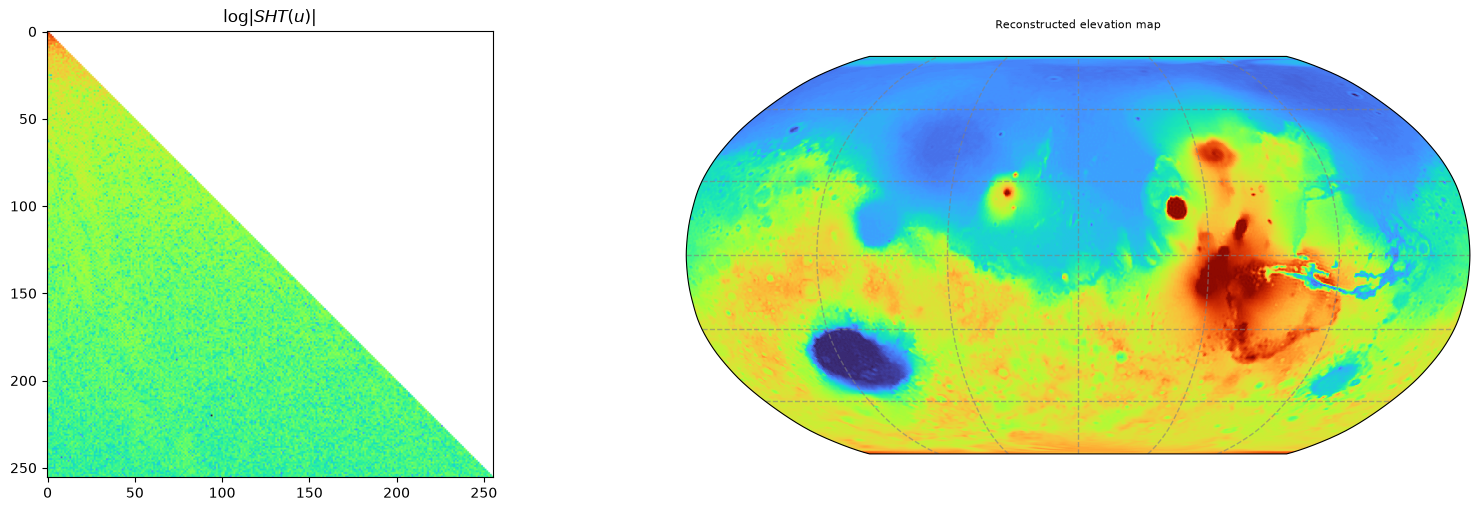

In [15]:
fig = plt.figure(figsize=(16, 5), layout="constrained")
subfigs = fig.subfigures(1, 2)

# spectral coefficients (keep as imshow)
ax = subfigs[0].add_subplot()
ax.imshow(coeffs.abs().log().cpu(), cmap=cmap)
ax.set_title("$\\log | SHT(u) |$")

plot_sphere(isht(coeffs).cpu(), fig=subfigs[1], cmap=cmap,
            title="Reconstructed elevation map", gridlines=True)

plt.show()

The round-trip $\mathrm{ISHT}(\mathrm{SHT}(u))$ is not exact because the equiangular
grid cannot resolve all modes — the highest frequencies are lost to truncation.
Let us plot the pointwise reconstruction error:

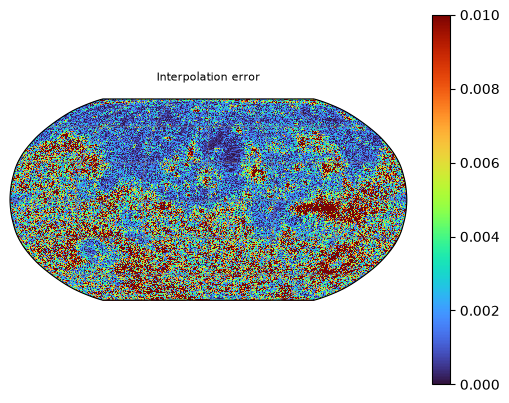

In [16]:
plot_sphere((isht(coeffs).cpu() - data).abs(), cmap=cmap,
            title="Interpolation error", colorbar=True, gridlines=True,
            vmin=0, vmax=0.01)

### Differentiability

Since the SHT and ISHT are implemented as PyTorch modules, they support automatic
differentiation out of the box. This lets us optimize spectral coefficients directly
with gradient descent.

As a demonstration, we define a small `SpectralModel` that holds learnable spectral
coefficients $\theta \in \mathbb{C}^{l_{\max} \times m_{\max}}$ and synthesizes a
grid field via the inverse SHT. We then fit these coefficients to match the Mars
elevation data by minimizing the mean squared error:

In [17]:
class SpectralModel(nn.Module):
    def __init__(self, n_modes, out_dims):
        super().__init__()
        self.isht = InverseRealSHT(out_dims[0], out_dims[1], lmax=n_modes, mmax=n_modes, grid="equiangular").to(device)
        self.coeffs = nn.Parameter(torch.randn(self.isht.lmax, self.isht.mmax, dtype=torch.complex128))

    def forward(self):
        return self.isht(self.coeffs)

sh_model = SpectralModel(120, (nlat, nlon)).to(device)
sh_model

SpectralModel(
  (isht): InverseRealSHT(
    nlat=512, nlon=1024,
     lmax=120, mmax=120,
     grid=equiangular, csphase=True
  )
)

We optimize the coefficients using Adam. Because the ISHT is differentiable,
gradients flow from the pixel-space loss all the way back to the spectral coefficients:

In [18]:
optimizer = torch.optim.Adam(sh_model.parameters(), lr = 5e-2)

pbar = tqdm(range(500), desc="Spectral fitting")
for iter in pbar:

    loss = (sh_model() - signal).pow(2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if iter % 10 == 0:
        pbar.set_postfix_str(f"loss={loss.item():.6f}")

Spectral fitting: 100%|██████████| 500/500 [00:06<00:00, 71.86it/s, loss=0.000257] 


Let us plot the approximation:

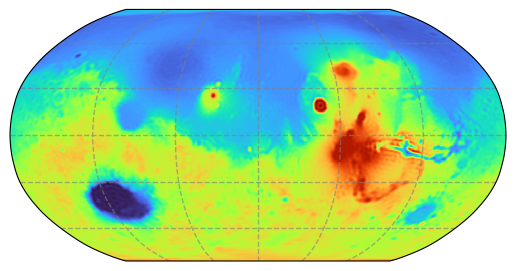

In [19]:
plot_sphere(sh_model().detach().cpu(), cmap=cmap, gridlines=True)

The model uses only 120 modes, so it cannot capture the finest details.
The error map shows where the band-limited approximation deviates from the full-resolution data:

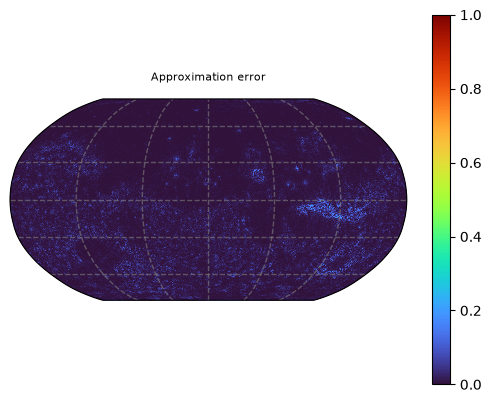

In [20]:
plot_sphere((sh_model().detach() - signal).abs().cpu(), cmap=cmap,
            title="Approximation error", colorbar=True, gridlines=True,
            vmin=0, vmax=1)

## Conclusion

This concludes our introduction to `torch-harmonics`.